# Tabular photo-z — MLP baseline (200k subset)

Single multi-layer perceptron on the SDSS tabular features.
Clean `-9999` sentinels, derive colors + log sizes, **subsample to 200k** (not the full 600k),
standardize, then train an MLP. Metrics: MAE, σ_MAD, outlier rate (|Δz/(1+z)| > 0.05).

In [1]:
# --- load + featurize + subsample to 200k ---
import pandas as pd, numpy as np
from sklearn.model_selection import train_test_split

cat = pd.read_parquet("../catalog_v1.parquet")          # 600k frozen catalog (repo root)
num = cat.select_dtypes("number").columns
cat[num] = cat[num].mask(cat[num] <= -100)              # clean SDSS -9999 "not measured" sentinel
for a, b in [("u", "g"), ("g", "r"), ("r", "i"), ("i", "z")]:
    cat[f"{a}-{b}"] = (cat[f"dered_{a}"] - cat[f"dered_{b}"]).clip(-1, 4)   # colors, clipped tails
for s in ["expRad_r", "deVRad_r", "petroRad_r", "petroR50_r", "petroR90_r"]:
    cat["log_" + s] = np.log1p(cat[s].clip(lower=0))                        # log right-skewed sizes
cat["conc_r"] = cat["petroR90_r"] / cat["petroR50_r"].replace(0, np.nan)

feats = ["dered_u","dered_g","dered_r","dered_i","dered_z", "g-r","u-g","r-i","i-z",
         "log_expRad_r","log_deVRad_r","log_petroRad_r","log_petroR50_r","log_petroR90_r",
         "fracDeV_r","conc_r"]

D = cat[feats + ["redshift"]].replace([np.inf, -np.inf], np.nan).dropna()
D = D.sample(200_000, random_state=0)                   # <-- 200k subset (not the full 600k)
Xtr, Xte, ytr, yte = train_test_split(D[feats], D["redshift"], test_size=0.3, random_state=42)
print(f"train={len(Xtr)}  test={len(Xte)}  features={len(feats)}")

train=140000  test=60000  features=16


In [7]:
# --- train the MLP (StandardScaler is required for neural nets) + evaluate ---
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

mlp = make_pipeline(
    StandardScaler(),
    MLPRegressor(hidden_layer_sizes=(64, 32, 16, 16, 8), activation="relu",
                 alpha=1e-4, batch_size=256, learning_rate_init=1e-3,
                 early_stopping=True, n_iter_no_change=12, max_iter=300, random_state=0),
)
mlp.fit(Xtr, ytr)
yp = mlp.predict(Xte)

dz = (yp - yte.values) / (1 + yte.values)
smad = 1.4826 * np.median(np.abs(dz - np.median(dz)))
epochs = mlp.named_steps["mlpregressor"].n_iter_
print(f"MLP 64-32-16-16-8 (200k):  MAE={np.mean(np.abs(yp - yte.values)):.4f}  "
      f"sigma_MAD={smad:.4f}  outlier={np.mean(np.abs(dz) > 0.05):.2%}  (epochs={epochs})")

# Reference (150k subset, same model): MAE 0.0156, sigma_MAD 0.0138, outlier 2.64%.
# More data usually helps a neural net a little, so 200k should match or slightly beat that.

MLP 64-32-16-16-8 (200k):  MAE=0.0160  sigma_MAD=0.0141  outlier=2.95%  (epochs=38)


In [6]:
# --- train the MLP (StandardScaler is required for neural nets) + evaluate ---
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

mlp1 = make_pipeline(
    StandardScaler(),
    MLPRegressor(hidden_layer_sizes=(128, 64, 32), activation="relu",
                 alpha=1e-4, batch_size=256, learning_rate_init=1e-3,
                 early_stopping=True, n_iter_no_change=12, max_iter=300, random_state=0),
)
mlp1.fit(Xtr, ytr)
yp = mlp1.predict(Xte)

dz = (yp - yte.values) / (1 + yte.values)
smad = 1.4826 * np.median(np.abs(dz - np.median(dz)))
epochs = mlp.named_steps["mlpregressor"].n_iter_
print(f"MLP1 128-64-32 (200k):  MAE={np.mean(np.abs(yp - yte.values)):.4f}  "
      f"sigma_MAD={smad:.4f}  outlier={np.mean(np.abs(dz) > 0.05):.2%}  (epochs={epochs})")

# Reference (150k subset, same model): MAE 0.0156, sigma_MAD 0.0138, outlier 2.64%.
# More data usually helps a neural net a little, so 200k should match or slightly beat that.

MLP1 128-64-32 (200k):  MAE=0.0155  sigma_MAD=0.0136  outlier=2.70%  (epochs=78)


## Diagnosing the 563 hard cases

The 563 galaxies that **all three models** (LR, RF, MLP) get wrong, and that stay wrong even after adding 60% of them to training, are exported in `hard563_objids.csv`. Here we compare their feature distributions against the normal population:
- **(A)** the 9 core mag/color features the model actually uses (+ redshift) — are the hard cases in an unusual region?
- **(B/C)** the other 55-column parquet features **not** used in training (errors, extinction, sizes, position) — does anything *outside* the model flag them (noisy photometry? a specific z? a spatial artifact)?

hard=563   normal=599437


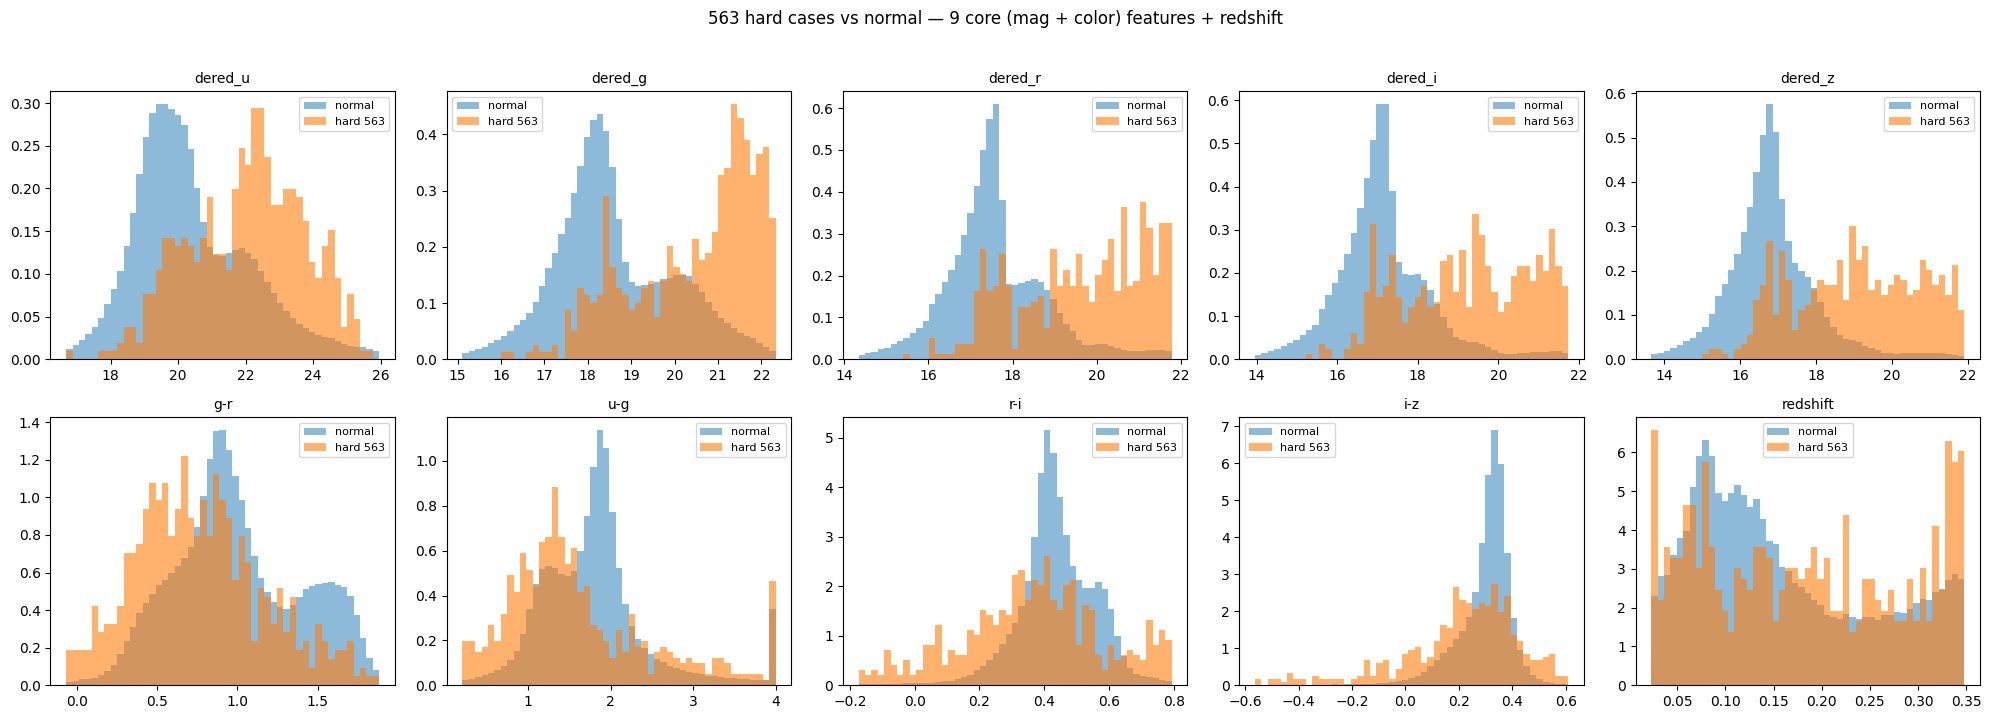

In [9]:
# === Diagnose the 563 "all-3-models" outliers: how do their feature distributions differ? ===
import pandas as pd, numpy as np, matplotlib.pyplot as plt

hard_ids = set(pd.read_csv("hard563_objids.csv")["objid"])     # exported earlier
c = pd.read_parquet("../catalog_v1.parquet")
nm = c.select_dtypes("number").columns
c[nm] = c[nm].mask(c[nm] <= -100)                              # clean -9999 sentinel
for a, b in [("u","g"), ("g","r"), ("r","i"), ("i","z")]:
    c[f"{a}-{b}"] = (c[f"dered_{a}"] - c[f"dered_{b}"]).clip(-1, 4)
hard = c["objid"].isin(hard_ids)
print(f"hard={hard.sum()}   normal={(~hard).sum()}")

# (A) the 9 core features the model leans on (+ redshift) — hard 563 vs normal population
core9 = ["dered_u","dered_g","dered_r","dered_i","dered_z","g-r","u-g","r-i","i-z","redshift"]
fig, axes = plt.subplots(2, 5, figsize=(20, 7))
for ax, col in zip(axes.ravel(), core9):
    r = c.loc[~hard, col].replace([np.inf, -np.inf], np.nan).dropna()
    h = c.loc[hard,  col].replace([np.inf, -np.inf], np.nan).dropna()
    bins = np.linspace(r.quantile(.005), r.quantile(.995), 50)
    ax.hist(r, bins=bins, density=True, alpha=.5, label="normal")
    ax.hist(h, bins=bins, density=True, alpha=.6, label="hard 563")
    ax.set_title(col, fontsize=10); ax.legend(fontsize=8)
plt.suptitle("563 hard cases vs normal — 9 core (mag + color) features + redshift", y=1.02)
plt.tight_layout(); plt.show()

In [10]:
# === (B) Do the 563 stand out in the OTHER 55-column parquet features (not used in training)? ===
# Standardized mean difference = (hard_mean - normal_mean) / normal_std, for every numeric column.
# |std_diff| > ~0.3 means the hard set is noticeably shifted in that feature.
TRAIN = {"dered_u","dered_g","dered_r","dered_i","dered_z","g-r","u-g","r-i","i-z",
         "expRad_r","deVRad_r","petroRad_r","petroR50_r","petroR90_r","fracDeV_r","conc_r"}
rows = []
for col in c.select_dtypes("number").columns:
    if col in ("objid", "specObjID"):
        continue
    r = c.loc[~hard, col].replace([np.inf, -np.inf], np.nan).dropna()
    h = c.loc[hard,  col].replace([np.inf, -np.inf], np.nan).dropna()
    if len(h) < 30 or r.std() == 0:
        continue
    grp = "model" if col in TRAIN else ("label/id" if col in
          ("redshift","zErr","zWarning","plate","mjd","fiberID","run","rerun","camcol","field","ra","dec") else "OTHER")
    rows.append((col, grp, round(h.median(), 4), round(r.median(), 4), round((h.mean()-r.mean())/r.std(), 2)))
diff = pd.DataFrame(rows, columns=["feature","group","hard_med","normal_med","std_diff"])
diff = diff.reindex(diff.std_diff.abs().sort_values(ascending=False).index).reset_index(drop=True)
print(diff.to_string(index=False))

      feature    group    hard_med  normal_med  std_diff
modelMagErr_r    OTHER      0.0371      0.0072      2.20
   modelMag_z    OTHER     19.3168     16.8017      1.88
      dered_z    model     19.2186     16.7594      1.87
   modelMag_i    OTHER     19.5672     17.1130      1.83
  cModelMag_z    OTHER     19.3070     16.8455      1.82
      dered_i    model     19.4641     17.0567      1.82
  cModelMag_i    OTHER     19.4908     17.1316      1.80
   petroMag_r    OTHER     20.2065     17.6185      1.77
   modelMag_r    OTHER     20.1884     17.5506      1.75
     psfMag_z    OTHER     20.0031     18.2082      1.75
  cModelMag_r    OTHER     20.1604     17.5448      1.75
      dered_r    model     20.0548     17.4755      1.74
modelMagErr_z    OTHER      0.0952      0.0178      1.71
     psfMag_i    OTHER     20.3192     18.5666      1.71
     psfMag_r    OTHER     20.8276     18.9953      1.64
  cModelMag_g    OTHER     21.1227     18.4159      1.41
   modelMag_g    OTHER     21.1

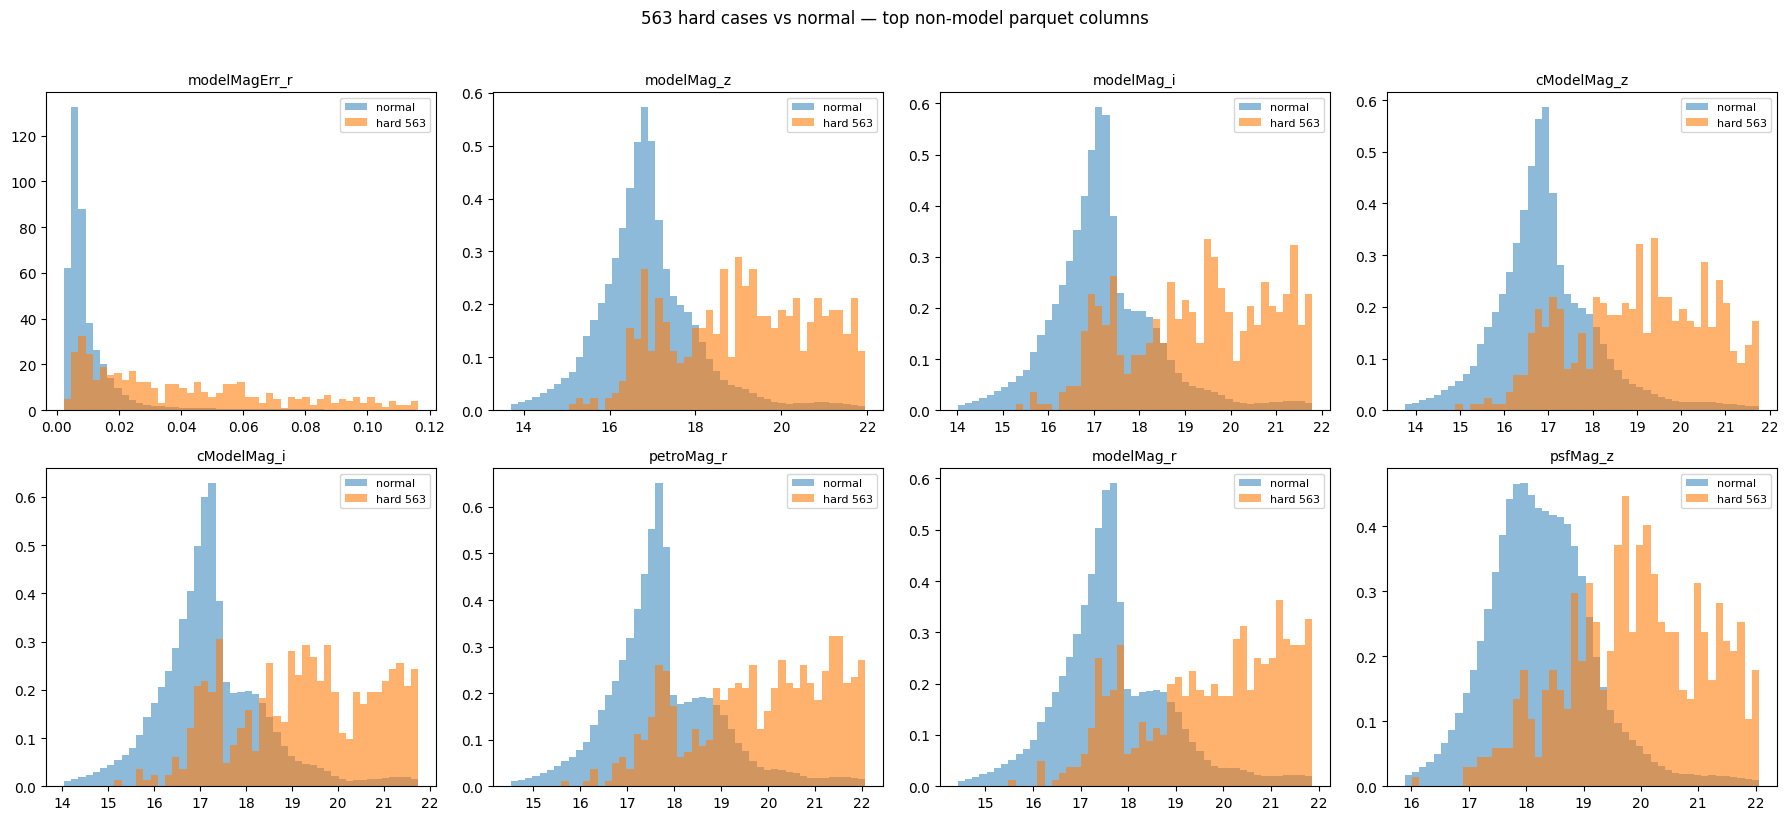

In [11]:
# === (C) plot the OTHER (non-model) parquet columns where the 563 differ most ===
top_other = diff[diff.group == "OTHER"].head(8)["feature"].tolist()
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for ax, col in zip(axes.ravel(), top_other):
    r = c.loc[~hard, col].replace([np.inf, -np.inf], np.nan).dropna()
    h = c.loc[hard,  col].replace([np.inf, -np.inf], np.nan).dropna()
    bins = np.linspace(r.quantile(.005), r.quantile(.995), 50)
    ax.hist(r, bins=bins, density=True, alpha=.5, label="normal")
    ax.hist(h, bins=bins, density=True, alpha=.6, label="hard 563")
    ax.set_title(col, fontsize=10); ax.legend(fontsize=8)
plt.suptitle("563 hard cases vs normal — top non-model parquet columns", y=1.02)
plt.tight_layout(); plt.show()

# What to look for:
#  - high *Err (photometric error) in the hard set  -> noisy photometry, not pure color degeneracy
#  - redshift piling up at a specific range         -> the degeneracy is z-localized
#  - ra/dec/run/camcol/field standing out           -> a spatial / instrumental artifact, not physics